# CS179 Project — Bayesian Network for Heart Disease Diagnosis

**Dataset:** UCI Heart Disease (Cleveland subset), 303 patients, 13 clinical features + binary diagnosis target.

**Goal:** Build a Bayesian network over symptoms, risk factors, and diagnosis to predict heart disease *with calibrated uncertainty*. Analyze the learned conditional-dependency structure for interpretability.

**This notebook (01):** load the data, document features, discretize continuous variables, and prepare a train/test split.

---


## 1. Imports & data load

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('heart_disease.csv')
print(f"Loaded {df.shape[0]} patients, {df.shape[1]} columns")
df.head()

Loaded 303 patients, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Feature documentation

| Column     | Meaning                                              | Type        | Values |
|------------|------------------------------------------------------|-------------|--------|
| `age`      | Age in years                                         | continuous  | 29–77 |
| `sex`      | Sex                                                  | binary      | 0 = female, 1 = male |
| `cp`       | Chest-pain type                                      | categorical | 0 = typical angina, 1 = atypical, 2 = non-anginal, 3 = asymptomatic |
| `trestbps` | Resting blood pressure (mm Hg)                       | continuous  | 94–200 |
| `chol`     | Serum cholesterol (mg/dl)                            | continuous  | 126–564 |
| `fbs`      | Fasting blood sugar > 120 mg/dl                      | binary      | 0 = no, 1 = yes |
| `restecg`  | Resting ECG result                                   | categorical | 0 = normal, 1 = ST-T abnormality, 2 = LV hypertrophy |
| `thalach`  | Maximum heart rate achieved                          | continuous  | 71–202 |
| `exang`    | Exercise-induced angina                              | binary      | 0 = no, 1 = yes |
| `oldpeak`  | ST depression induced by exercise vs. rest           | continuous  | 0.0–6.2 |
| `slope`    | Slope of peak-exercise ST segment                    | categorical | 0 = upsloping, 1 = flat, 2 = downsloping |
| `ca`       | # major vessels (0–3) colored by fluoroscopy         | categorical | 0–4 |
| `thal`     | Thalassemia                                          | categorical | 1 = fixed defect, 2 = normal, 3 = reversible defect |
| `target`   | Heart-disease diagnosis                              | binary      | 0 = absent, 1 = present |


In [27]:
print('Missing values per column:')
print(df.isnull().sum().to_string())
print(f"\nTarget balance: {df['target'].mean():.1%} positive (165 / 303)")
print(f"\nSex split:     {df['sex'].mean():.1%} male")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0

Target balance: 54.5% positive (165 / 303)

Sex split:     68.3% male


## 3. Quick exploratory plots

A few sanity-check distributions before we build the model.

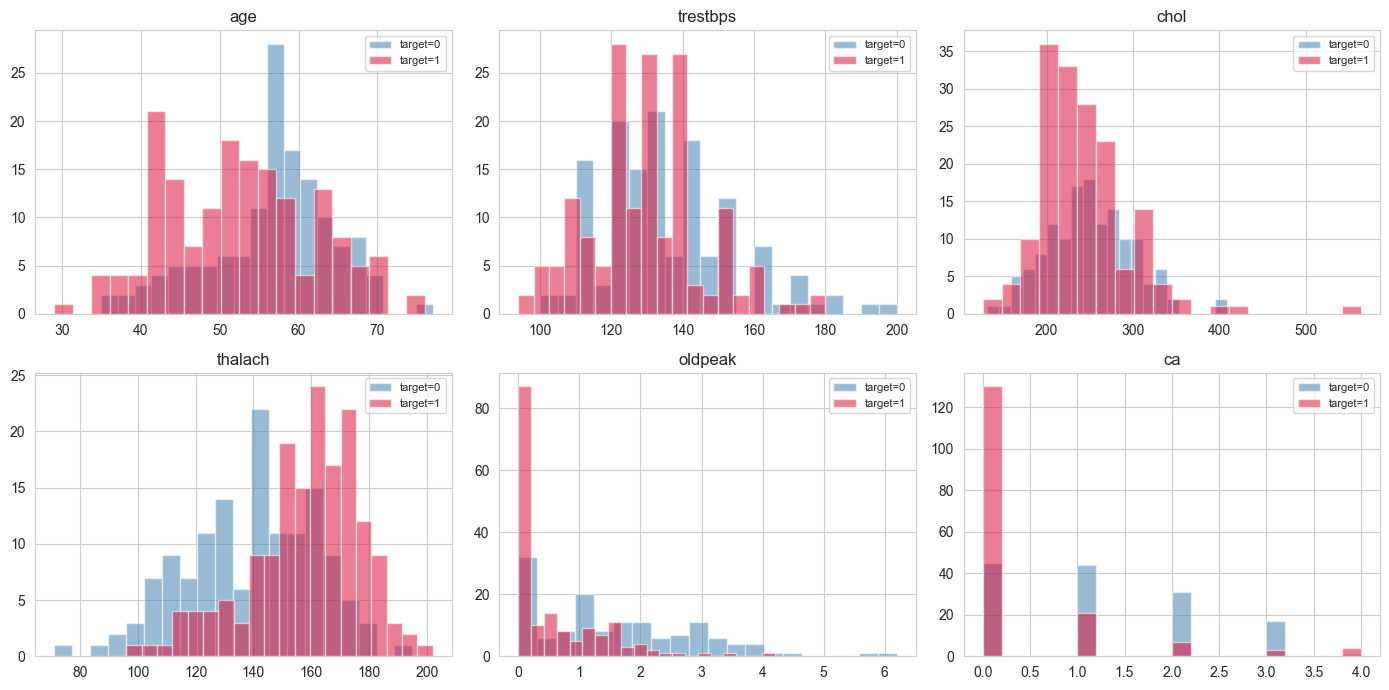

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.flat, ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']):
    for t, color in [(0, 'steelblue'), (1, 'crimson')]:
        ax.hist(df.loc[df.target == t, col], bins=20, alpha=0.55,
                label=f'target={t}', color=color)
    ax.set_title(col); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 4. Discretization

Discrete Bayesian networks need every variable to be categorical. Five features here are continuous (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) — we'll bin each into 3–4 clinically meaningful categories so the resulting CPTs stay interpretable.

Bin choices (clinical guidelines where possible):

- **age** → `young` (<45), `middle` (45–55), `older` (55–65), `senior` (≥65)
- **trestbps** (resting BP, AHA categories) → `normal` (<120), `elevated` (120–140), `high` (≥140)
- **chol** (NCEP categories) → `desirable` (<200), `borderline` (200–240), `high` (≥240)
- **thalach** (max HR) → `low` (<120), `moderate` (120–150), `high` (≥150)
- **oldpeak** (ST depression) → `none` (=0), `mild` (0–2), `marked` (≥2)


In [29]:
disc = df.copy()

disc['age']      = pd.cut(df['age'],      bins=[0, 45, 55, 65, 200],
                          labels=['young', 'middle', 'older', 'senior'])
disc['trestbps'] = pd.cut(df['trestbps'], bins=[0, 120, 140, 300],
                          labels=['normal', 'elevated', 'high'])
disc['chol']     = pd.cut(df['chol'],     bins=[0, 200, 240, 700],
                          labels=['desirable', 'borderline', 'high'])
disc['thalach']  = pd.cut(df['thalach'],  bins=[0, 120, 150, 250],
                          labels=['low', 'moderate', 'high'])
disc['oldpeak']  = pd.cut(df['oldpeak'],  bins=[-0.01, 0.0, 2.0, 10.0],
                          labels=['none', 'mild', 'marked'])

# Cast the rest to string categories so pgmpy treats them uniformly
for col in ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']:
    disc[col] = disc[col].astype(str)

for col in ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']:
    disc[col] = disc[col].astype(str)

print('Discretized distributions:')
for col in ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']:
    print(f"\n{col}:"); print(disc[col].value_counts().to_string())

Discretized distributions:

age:
age
older     118
middle     88
young      64
senior     33

trestbps:
trestbps
elevated    141
normal       97
high         65

chol:
chol
high          151
borderline    101
desirable      51

thalach:
thalach
high        164
moderate    102
low          37

oldpeak:
oldpeak
mild      154
none       99
marked     50


## 5. Train / test split & save

In [30]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(disc, test_size=0.20, random_state=179, stratify=disc['target'])

print(f'Train: {len(train)} rows | positive rate {train.target.astype(int).mean():.1%}')
print(f'Test:  {len(test)}  rows | positive rate {test.target.astype(int).mean():.1%}')

disc.to_csv('heart_discretized.csv', index=False)
train.to_csv('heart_train.csv', index=False)
test.to_csv('heart_test.csv', index=False)
print('\nSaved discretized / train / test CSVs to current directory')

Train: 242 rows | positive rate 54.5%
Test:  61  rows | positive rate 54.1%

Saved discretized / train / test CSVs to current directory


---

## Next steps (notebooks 02 & 03)

1. **Structure learning** — compare an expert-defined DAG against one learned by hill-climbing with the BIC score; visualize both.
2. **Parameter learning** — fit CPTs with Bayesian estimator (BDeu prior) so we have stable posteriors on the small dataset.
3. **Inference** — `VariableElimination` for `P(target | observed features)`; report posterior probabilities, not just hard predictions.
4. **Evaluation** — accuracy, ROC-AUC, **calibration curve** (the project's distinguishing contribution: *uncertainty quality*, not just point accuracy), and 5-fold CV.
5. **Interpretation** — read off the learned edges as conditional dependencies; check which match known cardiology risk factors.
